In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)

Dataset shape: (891, 15)


In [3]:
df_model = df.copy()

# Drop deck: 77.22% missing
df_model = df_model.drop(columns=["deck"])

# Drop rows where embarked / embark_town are missing
df_model = df_model.dropna(subset=["embarked", "embark_town"])

# Impute age using the median
df_model["age"] = df_model["age"].fillna(df_model["age"].median())

print("Cleaned modeling dataset:", df_model.shape)
print("Remaining missing values:", df_model.isnull().sum().sum())

Cleaned modeling dataset: (889, 14)
Remaining missing values: 0


In [4]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df_model[features]
y = df_model["survived"]

print("Features:")
print(features)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Target percentage:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (711, 7)
X_test: (178, 7)
y_train: (711,)
y_test: (178,)

Training class distribution:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Test class distribution:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64


## Stratified Train/Test Split

The `survived` target contains two classes, and the classes are not evenly distributed. Stratification is used so that the training and test sets preserve approximately the same proportion of survived and non-survived passengers.

An 80/20 train/test split is used with `random_state=42` for reproducibility. The split is performed before preprocessing so that information from the test set does not influence preprocessing or model training.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [7]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline

print("All 3 classifiers trained successfully.")

All 3 classifiers trained successfully.


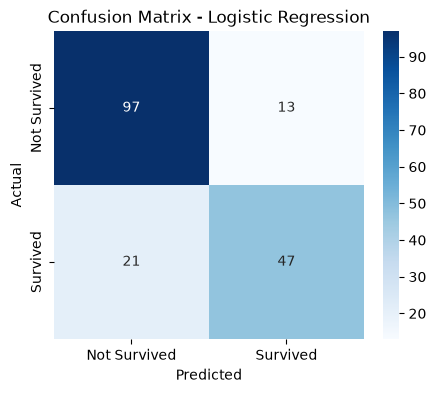

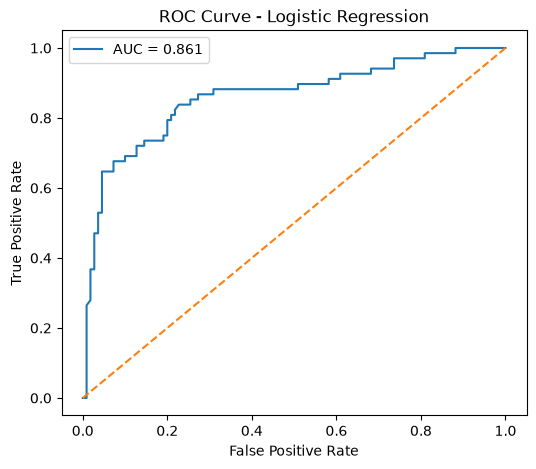

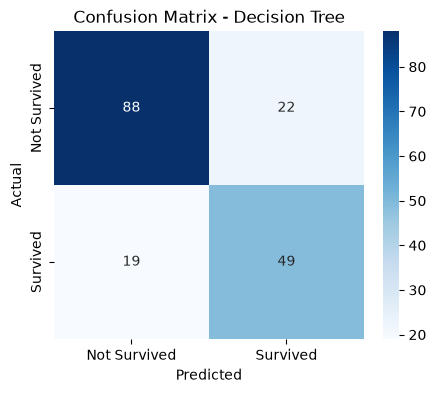

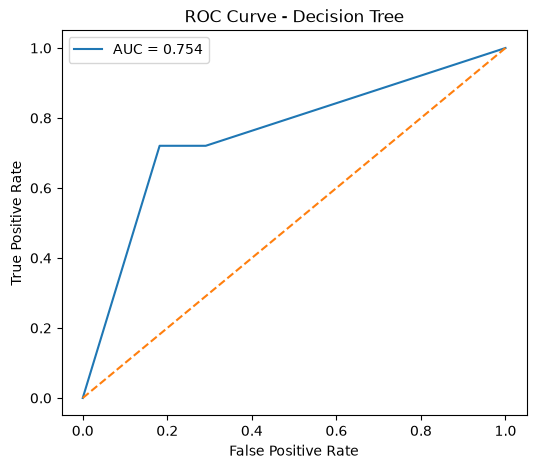

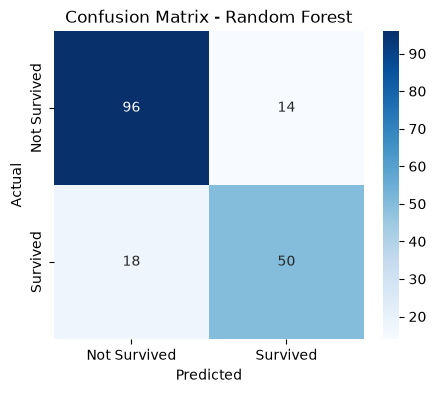

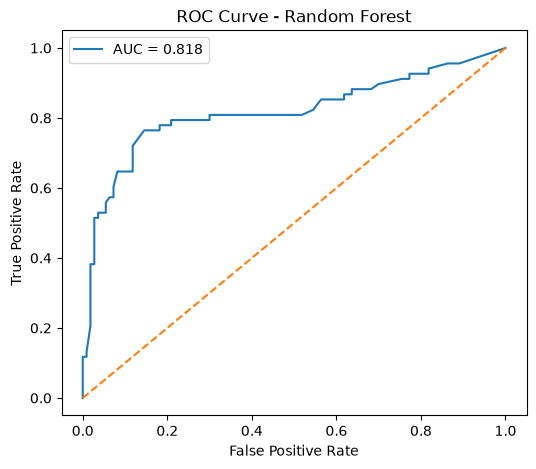

Model Comparison:


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179


In [9]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

results = []

for name, pipeline in pipelines.items():
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Survived", "Survived"],
        yticklabels=["Not Survived", "Survived"]
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Comparison table
results_df = pd.DataFrame(results)

print("Model Comparison:")
display(results_df.round(4))

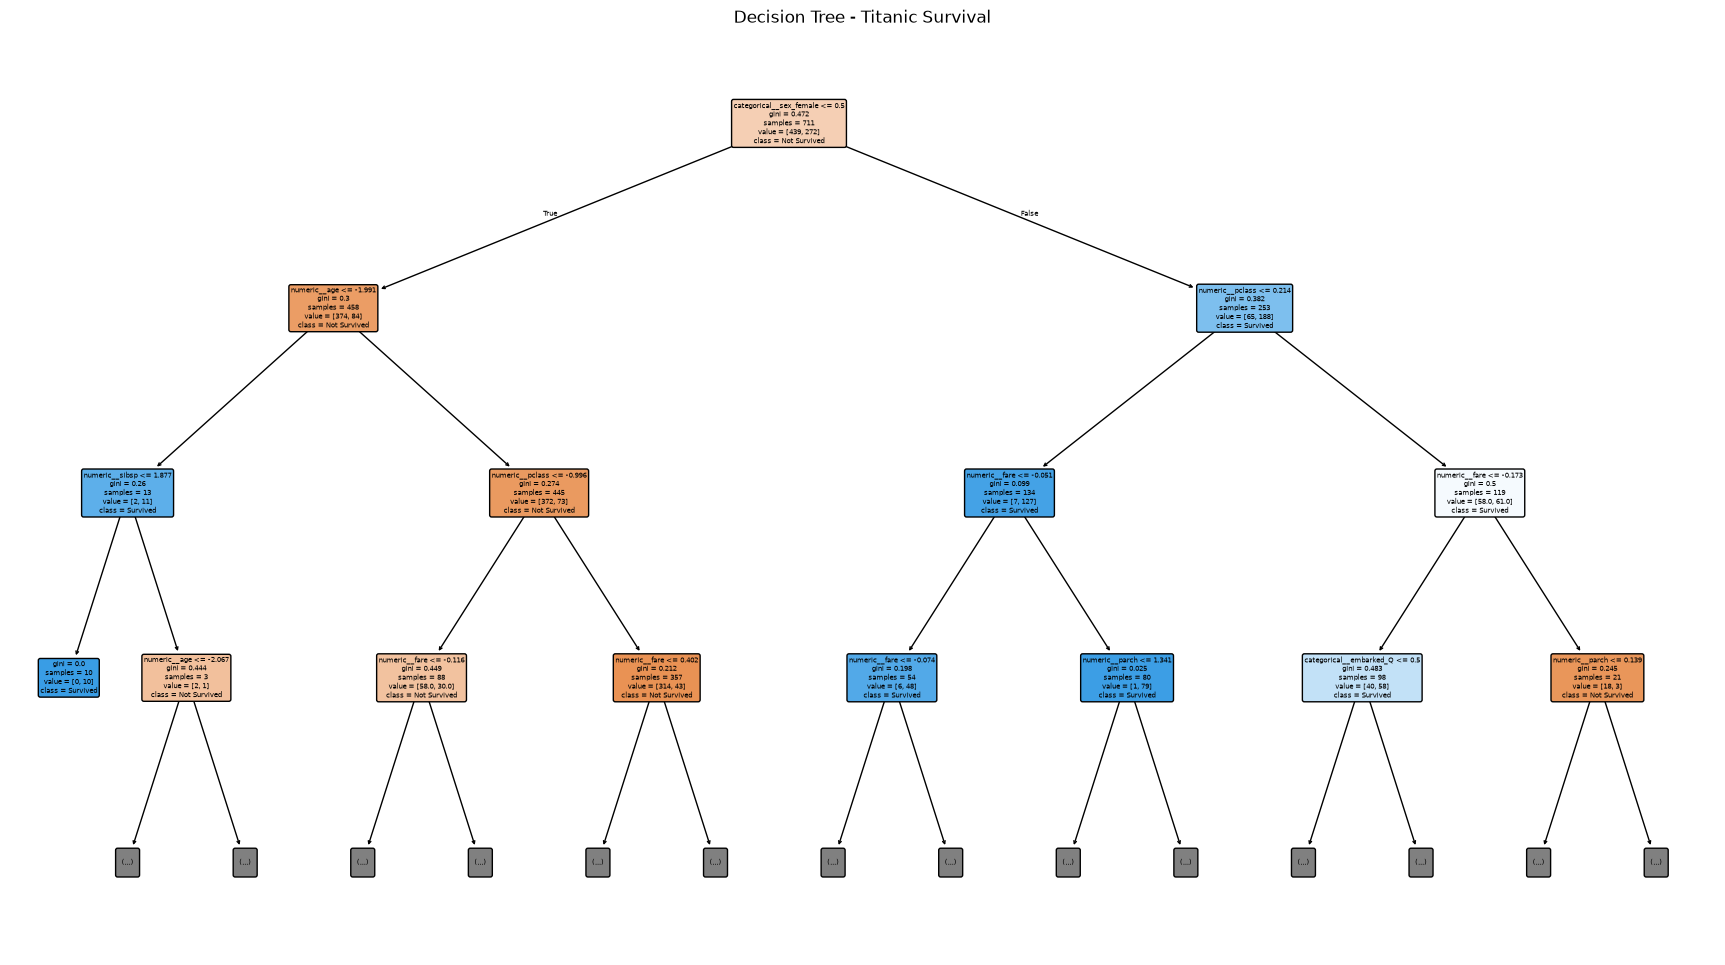

In [10]:
from sklearn.tree import plot_tree

decision_tree_pipeline = pipelines["Decision Tree"]

# Get the trained Decision Tree
tree_model = decision_tree_pipeline.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = decision_tree_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree - Titanic Survival")
plt.show()

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score

imbalance_results = []

# 1. Baseline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

imbalance_results.append({
    "Strategy": "Baseline",
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred)
})


# 2. Class Weight = Balanced
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)
balanced_pred = balanced_model.predict(X_test)

imbalance_results.append({
    "Strategy": "Class Weight = Balanced",
    "Precision": precision_score(y_test, balanced_pred),
    "Recall": recall_score(y_test, balanced_pred),
    "F1": f1_score(y_test, balanced_pred)
})


# 3. SMOTE — training data only
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

X_test_processed = preprocessor.transform(X_test)
smote_pred = smote_model.predict(X_test_processed)

imbalance_results.append({
    "Strategy": "SMOTE",
    "Precision": precision_score(y_test, smote_pred),
    "Recall": recall_score(y_test, smote_pred),
    "F1": f1_score(y_test, smote_pred)
})


# Comparison
imbalance_df = pd.DataFrame(imbalance_results)

display(imbalance_df.round(4))

,Strategy,Precision,Recall,F1
0,Baseline,0.7833,0.6912,0.7344
1,Class Weight = Balanced,0.7183,0.7500,0.7338
2,SMOTE,0.7353,0.7353,0.7353


The baseline model has the highest precision (0.7833), while class weighting produces the highest recall (0.7500). SMOTE gives equal precision and recall of 0.7353 and the highest F1-score (0.7353), although the F1 differences between the three approaches are very small. Overall, SMOTE provides the most balanced precision-recall result in this experiment, while class weighting is useful when identifying more surviving passengers is the priority.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

best_rf_pipeline = grid_search.best_estimator_

print("\nOOB Score:")
print(best_rf_pipeline.named_steps["classifier"].oob_score_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1:
0.7408312771917277

OOB Score:
0.8213783403656821


### Random Forest Tuning Interpretation

GridSearchCV identified a Random Forest with 200 trees, a maximum depth of 5, and `sqrt` for the maximum number of features considered at each split. The best cross-validation F1-score was 0.7408. The corresponding out-of-bag (OOB) score was 0.8214, providing an additional estimate of the model's performance using the unused samples from the bootstrap training process.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
X_reg = df_model.drop(columns=["fare", "survived"])
y_reg = df_model["fare"]

# Identify feature types
reg_numeric = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
reg_categorical = X_reg.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", reg_numeric)
print("Categorical features:", reg_categorical)

# Train/test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Preprocessing
reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric),
    ("categorical", reg_categorical_pipeline, reg_categorical)
])

# Regression pipeline
regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

# Train
regression_pipeline.fit(X_reg_train, y_reg_train)

# Predict
y_reg_pred = regression_pipeline.predict(X_reg_test)

# Metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

# Adjusted R²
n = len(y_reg_test)

X_reg_test_transformed = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test)

p = X_reg_test_transformed.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\nRegression Results")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

Numeric features: ['pclass', 'age', 'sibsp', 'parch']
Categorical features: ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Regression Results
MAE: 18.3735
RMSE: 41.2921
R²: 0.3609
Adjusted R²: 0.2607


C:\Users\kalag\AppData\Local\Temp\ipykernel_23260\1330216452.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  reg_categorical = X_reg.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [14]:
# Features and target
# Exclude fare (target) and survival-status fields
X_reg = df_model.drop(columns=["fare", "survived", "alive"])
y_reg = df_model["fare"]

# Identify feature types
reg_numeric = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical = X_reg.select_dtypes(
    include=["str", "category", "bool"]
).columns.tolist()

print("Numeric features:", reg_numeric)
print("Categorical features:", reg_categorical)

# Train/test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Numeric preprocessing
reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessing
reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric),
    ("categorical", reg_categorical_pipeline, reg_categorical)
])

# Regression pipeline
regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

# Train
regression_pipeline.fit(X_reg_train, y_reg_train)

# Predict
y_reg_pred = regression_pipeline.predict(X_reg_test)

# Metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

# Adjusted R²
n = len(y_reg_test)

X_reg_test_transformed = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test)

p = X_reg_test_transformed.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("\nRegression Results")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

Numeric features: ['pclass', 'age', 'sibsp', 'parch']
Categorical features: ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone']

Regression Results
MAE: 18.3945
RMSE: 41.3578
R²: 0.3589
Adjusted R²: 0.2679


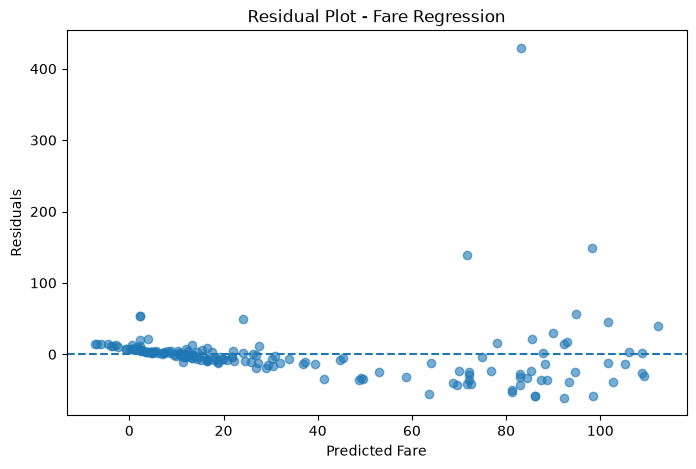

In [15]:
# Residuals
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Fare Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.show()

### Residual Analysis

The residual plot shows a clear non-random pattern in the spread of residuals. The residual variance increases as the predicted fare increases, with substantially larger deviations at higher predicted fare values. Therefore, the regression model shows evidence of heteroscedasticity, meaning the residual variance is not constant across the range of predicted fares.

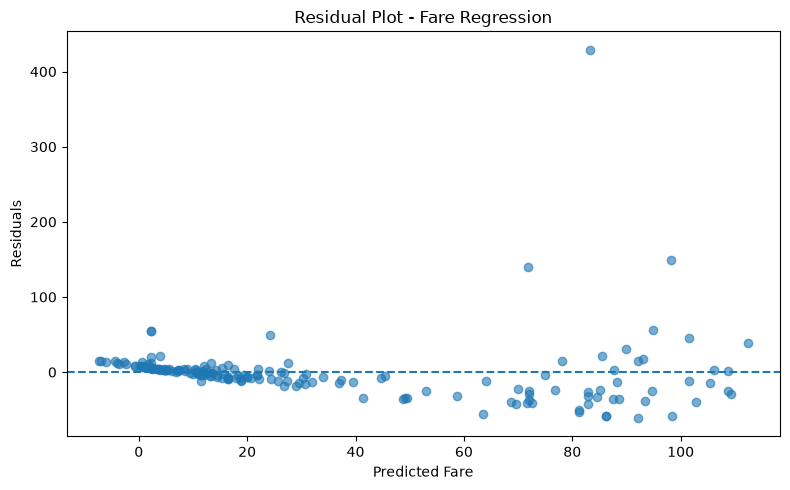

In [16]:
# Residual plot
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Fare Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.tight_layout()
plt.savefig("outputs/regression_residual_plot.png", dpi=150)
plt.show()

In [17]:
# Evaluate the tuned Random Forest on the test set

best_rf_pred = best_rf_pipeline.predict(X_test)
best_rf_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
best_rf_precision = precision_score(y_test, best_rf_pred)
best_rf_recall = recall_score(y_test, best_rf_pred)
best_rf_f1 = f1_score(y_test, best_rf_pred)
best_rf_auc = roc_auc_score(y_test, best_rf_prob)

tuned_rf_results = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": best_rf_accuracy,
    "Precision": best_rf_precision,
    "Recall": best_rf_recall,
    "F1": best_rf_f1,
    "AUC": best_rf_auc
}])

display(tuned_rf_results.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Tuned Random Forest,0.8315,0.8654,0.6618,0.75,0.8389


In [18]:
# Add tuned Random Forest to the original model results
final_classifier_results = results_df.copy()

final_classifier_results = pd.concat(
    [
        final_classifier_results,
        tuned_rf_results
    ],
    ignore_index=True
)

print("Final Classifier Comparison:")
display(final_classifier_results.round(4))

Final Classifier Comparison:


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179
3,Tuned Random Forest,0.8315,0.8654,0.6618,0.7500,0.8389


## Final Model Comparison and Deployment Recommendation

Among the tested classifiers, the tuned Random Forest achieved the highest test accuracy (0.8315) and the highest precision (0.8654), with an F1-score of 0.7500. Logistic Regression achieved the highest AUC (0.8610) and a recall of 0.6912, while the tuned Random Forest had a lower recall of 0.6618. The Decision Tree produced lower overall test metrics, with an accuracy of 0.7700 and AUC of 0.7540. Based on the test-set accuracy, precision, and F1-score, the tuned Random Forest is selected as the deployment model, while recognizing that Logistic Regression achieved the higher AUC and that recall differs between the models.

In [19]:
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
Path("models").mkdir(exist_ok=True)

# Save the COMPLETE fitted pipeline
model_path = "models/best_tuned_random_forest_pipeline.joblib"

joblib.dump(
    best_rf_pipeline,
    model_path
)

print(f"Pipeline saved successfully: {model_path}")

Pipeline saved successfully: models/best_tuned_random_forest_pipeline.joblib


In [20]:
# Reload the saved complete pipeline
loaded_pipeline = joblib.load(model_path)

# Use RAW X_test data
sample_raw = X_test.head(5)

# Predictions directly from raw input
sample_predictions = loaded_pipeline.predict(sample_raw)

print("Reloaded pipeline successfully.")
print("\nRaw input:")
display(sample_raw)

print("\nPredictions:")
print(sample_predictions)

Reloaded pipeline successfully.

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked
160,3,male,44.0,0,1,16.100,S
126,3,male,28.0,0,0,7.750,Q
428,3,male,28.0,0,0,7.750,Q
422,3,male,29.0,0,0,7.875,S
565,3,male,24.0,2,0,24.150,S



Predictions:
[0 0 0 0 0]


In [21]:
loaded_pipeline.predict(sample_raw)

array([0, 0, 0, 0, 0])